# Otimizadores em Redes Neurais
### Victor Emanuel Ruas Lima

## Sumário

1. [Introdução](#1-introdução)
   - 1.1 [Divisão dos dados](#11-divisão-dos-dados)
   - 1.2 [Curva de aprendizado](#12-curva-de-aprendizado)
2. [Gradiente Descendente](#2-gradiente-descendente)
   - 2.1 [Variantes do Gradiente Descendente](#21-variantes-do-gradiente-descendente)
3. [Momento](#3-momento)
   - 3.1 [Implementação em Python puro](#31-implementação-do-momento-em-python-puro)
   - 3.2 [Curva de Convergência](#32-curva-de-convergência-do-momento)
4. [AdaGrad](#4-adagrad)
   - 4.1 [Implementação em Python puro](#41-implementação-do-adagrad-em-python-puro)
   - 4.2 [Curva de Convergência](#42-curva-de-convergência-do-adagrad)
5. [RMSProp](#5-rmsprop)
   - 5.1 [Implementação em Python puro](#51-implementação-do-rmsprop-em-python-puro)
   - 5.2 [Curva de Convergência](#52-curva-de-convergência-do-rmsprop)
6. [Adam](#6-adam)
   - 6.1 [Implementação em Python puro](#61-implementação-do-adam-em-python-puro)
   - 6.2 [Curva de Convergência](#62-curva-de-convergência-do-adam)
7. [Learning Rate Scheduling](#7-learning-rate-scheduling)
8. [Referências](#8-referências)


## 1. Introdução

Neste notebook vamos explorar os principais otimizadores utilizados no treinamentode redes neurais. Antes de entender os otimizadores em si, precisamos entender o contexto em que eles atuam: como os dados são divididos e como acompanhamos o aprendizado do modelo.

> **Nota sobre uso de IA**: A implementação dos otimizadores AdaGrad, RMSProp e Adam
> em Python puro (seções 4.1, 5.1 e 6.1) foi realizada com auxílio de um modelo de
> linguagem. O log da conversa está disponível nas referências.

### 1.1 Divisão dos dados

Quando treinamos uma rede neural, queremos que ela aprenda padrões gerais e não que ela decore os exemplos de treino. Para medir isso com honestidade, dividimos os dados em três conjuntos:

- **Treino**: onde o modelo aprende e onde os pesos são ajustados
- **Validação**: acompanhamos o aprendizado *durante* o treino, sem ajustar pesos.
  Usamos para tomar decisões: qual otimizador? Qual taxa de aprendizado?
- **Teste**: medimos o desempenho final *uma única vez*, no fim do desenvolvimento.

A validação e o teste existem separados por um motivo importante: cada vez que olhamos para a validação e ajustamos algo no modelo, estamos indiretamente adaptando o modelo àquele conjunto. Se usássemos esse mesmo conjunto para medir o resultado final, o número seria otimista e desonesto. O teste precisa ser "virgem", olhado apenas uma vez no final.

### 1.2 Curva de aprendizado

Durante o treino, registramos o erro (loss) ao longo das épocas tanto no treino quanto na validação. O gráfico disso é a **curva de aprendizado**.
A partir da curva de aprendizado, é possível diagnosticar o que está acontecendo com o modelo.

Existem três situações clássicas:

- **Bom treino**: as duas curvas caem juntas e ficam próximas. O modelo aprendeu.
- **Underfitting**: as duas curvas ficam altas. O modelo não aprendeu nem os dados
  de treino. Isso ocorre porque, provavelmente, a rede é simples demais ou foi treinado por poucas épocas.
- **Overfitting**: a loss de treino cai, mas a de validação para ou começa a subir.

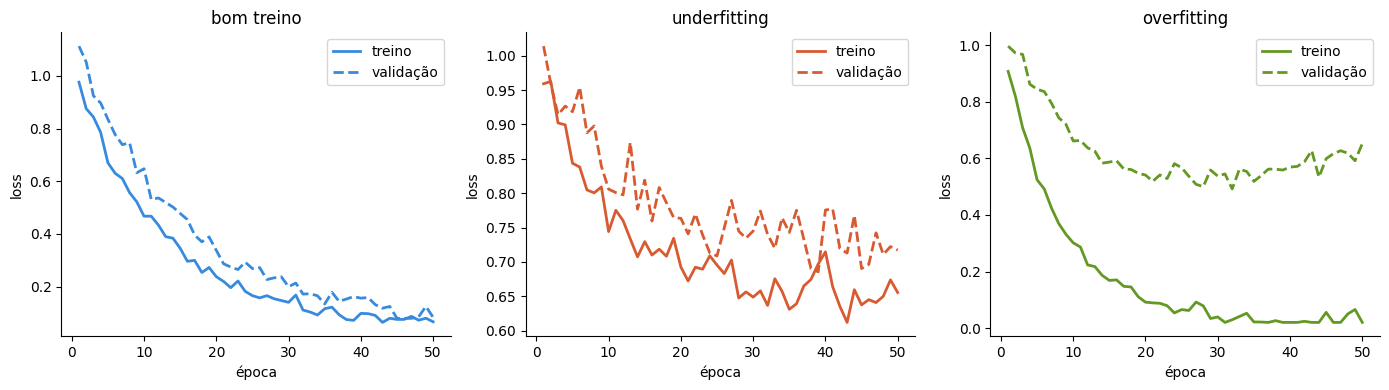

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
epochs = np.arange(1, 51)

def noise(scale, size):
    return rng.normal(0, scale, size)

# bom treino
train_good = np.maximum(0.05, np.exp(-epochs / 12) + 0.05 + noise(0.02, 50))
val_good   = np.maximum(0.08, 1.1 * np.exp(-epochs / 14) + 0.08 + noise(0.03, 50))

# underfitting
train_under = np.maximum(0.55, 1.0 - 0.35 * (1 - np.exp(-epochs / 10)) + noise(0.02, 50))
val_under   = np.maximum(0.58, 1.05 - 0.33 * (1 - np.exp(-epochs / 10)) + noise(0.03, 50))

# overfitting
train_over = np.maximum(0.02, np.exp(-epochs / 8) + 0.02 + noise(0.015, 50))
val_over   = np.maximum(0.15, 0.9 * np.exp(-epochs / 20) + 0.15 +
             np.where(epochs > 15, 0.012 * (epochs - 15), 0) + noise(0.025, 50))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

configs = [
    (train_good,  val_good,  "bom treino",  "#378ADD"),
    (train_under, val_under, "underfitting", "#D85A30"),
    (train_over,  val_over,  "overfitting",  "#639922"),
]

for ax, (train, val, title, color) in zip(axes, configs):
    ax.plot(epochs, train, color=color, lw=2,           label="treino")
    ax.plot(epochs, val,   color=color, lw=2, ls="--",  label="validação")
    ax.set_title(title)
    ax.set_xlabel("época")
    ax.set_ylabel("loss")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("curvas_aprendizado.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Gradiente Descendente

Imaginemos que estamos vendados no topo de uma montanha e queremos ir para o ponto mais baixo dela. A estratégia mais lógica seria darmos passos em direção à descida da montanha. Nesse momento, entra o gradiente, que aponta para onde
a montanha sobe, então devemos ir na direção oposta a ele, assim como o nome sugere: uma descida do gradiente.

A regra de atualização dos pesos é:

$$w_{t+1} = w_t - \eta \cdot \nabla L$$

Onde $w$ é o peso, $\eta$ é a taxa de aprendizado e $\nabla L$ é o gradiente da função de perda.

Diferentemente do SGD puro, devemos nos atentar ao valor de $\eta$. Uma taxa de aprendizado baixa faria com que o vale fosse alcançado de maneira muito lenta ou que os nossos valores ficassem presos num mínimo local. Já uma taxa de aprendizado alta pode fazer com que os nossos valores fiquem oscilando em torno do mínimo.

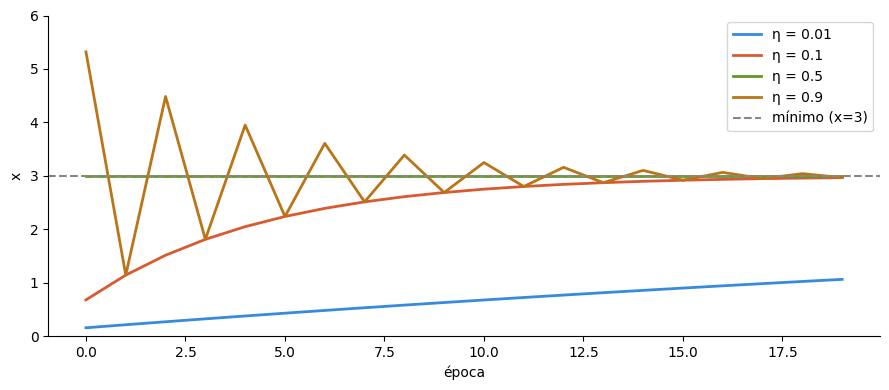

In [2]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(20)
x0 = 0.1
minimum = 3.0

def gradient_descent(lr, steps=20):
    x = x0
    trajectory = []
    for _ in range(steps):
        grad = 2 * (x - minimum)
        x = x - lr * grad
        trajectory.append(x)
    return np.array(trajectory)

lrs = [0.01, 0.1, 0.5, 0.9]
colors = ["#378ADD", "#D85A30", "#639922", "#BA7517"]

fig, ax = plt.subplots(figsize=(9, 4))

for lr, color in zip(lrs, colors):
    traj = gradient_descent(lr)
    ax.plot(epochs, traj, color=color, lw=2, label=f"η = {lr}")

ax.axhline(minimum, color="#888780", lw=1.5, ls="--", label="mínimo (x=3)")

ax.set_xlabel("época")
ax.set_ylabel("x")
ax.set_ylim(0, 6)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("convergencia_gd.png", dpi=150, bbox_inches="tight")
plt.show()

No gráfico acima é possível visualizar a convergência do Gradiente Descendente com diferentes taxas de aprendizado. Com a taxa mais baixa, de 0,01, ficou bastante longe do mínimo esperado de 3. A taxa de 0,1 alcançou um valor bem próximo, porém com uma certa demora. A taxa de 0,5 se mostrou como a melhor, convergindo rapidamente para o mínimo. Já a maior taxa, de 0,9, demonstrou um padrão oscilatório em torno do mínimo.

### 2.1 Variantes do Gradiente Descendente

Existem 3 diferentes variantes do gradiente descendente:

- **Gradiente Descendente** *(GD batch)*: Utiliza todo o dataset para calcular
  um gradiente e dar um passo. É bastante preciso porém é lento e caro
  computacionalmente.
- **SGD** *(Stochastic Gradient Descent)*: Utiliza apenas um exemplo aleatório
  por vez para o cálculo do gradiente. É rápido, porém ruidoso, visto que
  diferentes exemplos podem não apresentar o padrão dos dados.
- **Mini-batch**: Utiliza um pequeno lote (de ~32 a ~64 exemplos) e então tira
  a média desses exemplos. É razoável na precisão e eficiente computacionalmente.

Apesar da imprecisão, quando dizemos SGD, normalmente nos referimos ao Mini-batch.

### 3. Momento

Em vez de passos para descer uma montanha, imaginemos que agora uma bola rola pela montanha. Essa bola acumula velocidade conforme desce a montanha e não para a cada passo para calcular o próximo.

A ideia do Momento é exatamente essa: diferentemente do SGD puro, em vez de considerar apenas o gradiente da posição, o momento guarda uma média dos gradientes anteriores e usa isso para influenciar o passo atual. Se os últimos gradientes apontaram na mesma direção, o passo fica maior. Se a direção mudou, o passo reduz.

A regra de atualização vira a seguinte:

$$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot \nabla L$$

$$w_{t+1} = w_t - \eta \cdot v_t$$

Onde $v_t$ é a velocidade acumulada no passo $t$, $\beta$ é o coeficiente de momento (tipicamente $0,9$), $\eta$ é a taxa de aprendizado e $\nabla L$ é o gradiente da função de perda.

### 3.1 Implementação do Momento em Python puro

As classes abaixo foram adaptadas do material da disciplina de Redes Neurais e
Algoritmos Genéticos.

In [3]:
import math


class Valor:
    def __init__(self, data, progenitor=(), operador_mae="", rotulo=""):
        self.data = data
        self.progenitor = progenitor
        self.operador_mae = operador_mae
        self.rotulo = rotulo
        self.grad = 0

    def __str__(self):
        if self.rotulo:
            return f"Valor(data={self.data}), rotulo={self.rotulo})"
        else:
            return f"Valor(data={self.data})"

    def __repr__(self):
        data = self.data
        progenitor = self.progenitor
        operador_mae = self.operador_mae
        rotulo = self.rotulo

        argumentos = [f"{data=}"]

        if progenitor:
            argumentos.extend([f"{progenitor=}", f"{operador_mae=}"])
        if rotulo:
            argumentos.append(f"{rotulo=}")

        argumentos = ', '.join(argumentos)

        return f"Valor({argumentos})"

    def __add__(self, outro_valor):
        """Realiza a operação: self + outro_valor."""

        if not isinstance(outro_valor, Valor):
            outro_valor = Valor(outro_valor)

        progenitor = (self, outro_valor)
        data = self.data + outro_valor.data
        operador_mae = "+"
        resultado = Valor(data, progenitor, operador_mae)

        def propagar_adicao():
            self.grad += resultado.grad
            outro_valor.grad += resultado.grad

        resultado.propagar = propagar_adicao

        return resultado

    def __mul__(self, outro_valor):
        """Realiza a operação: self * outro_valor."""

        if not isinstance(outro_valor, Valor):
            outro_valor = Valor(outro_valor)

        progenitor = (self, outro_valor)
        data = self.data * outro_valor.data
        operador_mae = "*"
        resultado = Valor(data, progenitor, operador_mae)

        def propagar_multiplicacao():
            self.grad += resultado.grad * outro_valor.data # grad_filho * derivada filho em relação a mãe
            outro_valor.grad += resultado.grad * self.data

        resultado.propagar = propagar_multiplicacao

        return resultado

    def __pow__(self, expoente):
        """Realiza a operação: self ** expoente"""
        assert isinstance(expoente, (int, float))
        progenitor = (self, )
        data = self.data ** expoente
        operador_mae = f"**{expoente}"
        resultado = Valor(data, progenitor, operador_mae)

        def propagar_pow():
            self.grad += resultado.grad * (expoente * self.data ** (expoente - 1))

        resultado.propagar = propagar_pow

        return resultado

    def __truediv__(self, outro_valor):
        """Realiza a operação: self / outro_valor"""
        return self * outro_valor ** (-1)

    def __rtruediv__(self, outro_valor):
        """Realiza a operação: outro_valor / self"""
        return outro_valor * self ** (-1)

    def __neg__(self):
        """Realiza a operação: -self"""
        return self * -1

    def __sub__(self, outro_valor):
        """Realiza a operação: self - outro_valor"""
        return self + (-outro_valor)

    def __radd__(self, outro_valor):
        """Realiza a operação: outro_valor + self"""
        return self + outro_valor

    def __rsub__(self, outro_valor):
        """Realiza a operação: outro_valor - self"""
        return outro_valor + (-self)

    def __rmul__(self, outro_valor):
        """Realiza a operação: outro_valor * self"""
        return self * outro_valor

    def exp(self):
        """Realiza a operação: exp(self)"""
        progenitor = (self, )
        data = math.exp(self.data)
        operador_mae = "exp"
        resultado = Valor(data, progenitor, operador_mae)

        def propagar_exp():
            self.grad += resultado.grad * data

        resultado.propagar = propagar_exp

        return resultado

    def sig(self):
        """Realiza a operação: 1 / (1 + exp(-self))

        Esta operação é equivalente a "exp(self) / (exp(self) + 1)", porém tem
        maior estabilidade numérica.
        """

        return 1 / (1 + (-self).exp())

    def propagar(self):
        pass

    def propagar_tudo(self):

        self.grad = 1

        ordem_topologica = []

        visitados = set()

        def constroi_ordem_topologica(v):
            if v not in visitados:
                visitados.add(v)
                for progenitor in v.progenitor:
                    constroi_ordem_topologica(progenitor)
                ordem_topologica.append(v)

        constroi_ordem_topologica(self)

        for vertice in reversed(ordem_topologica):
            vertice.propagar()

In [4]:
import random


class Neuronio:
    def __init__(self, num_dados_entrada):
        self.vies = Valor(random.uniform(-1, 1))

        self.pesos = []
        for i in range(num_dados_entrada):
            self.pesos.append(Valor(random.uniform(-1, 1)))

    def __call__(self, x):

        assert len(x) == len(self.pesos)

        soma = 0
        for info_entrada, peso_interno in zip(x, self.pesos):
            soma += info_entrada * peso_interno

        soma += self.vies
        dado_de_saida = soma.sig()

        return dado_de_saida

    def parametros(self):
        return self.pesos + [self.vies]

In [5]:
class Camada:
    def __init__(self, num_neuronios, num_dados_entrada):
        neuronios = []

        for _ in range(num_neuronios):
            neuronio = Neuronio(num_dados_entrada)
            neuronios.append(neuronio)

        self.neuronios = neuronios

    def __call__(self, x):
        dados_de_saida = []

        for neuronio in self.neuronios:
            informacao = neuronio(x)
            dados_de_saida.append(informacao)

        if len(dados_de_saida) == 1:
            return dados_de_saida[0]
        else:
            return dados_de_saida

    def parametros(self):
        params = []

        for neuronio in self.neuronios:
            params_neuronio = neuronio.parametros()
            params.extend(params_neuronio)

        return params

In [6]:
class MLP:
    def __init__(self, num_dados_entrada, num_neuronios_por_camada):

        percurso = [num_dados_entrada] + num_neuronios_por_camada

        camadas = []

        for i in range(len(num_neuronios_por_camada)):
            camada = Camada(num_neuronios_por_camada[i], percurso[i])
            camadas.append(camada)

        self.camadas = camadas

    def __call__(self, x):
        for camada in self.camadas:
            x = camada(x)
        return x

    def parametros(self):
        params = []

        for camada in self.camadas:
            parametros_camada = camada.parametros()
            params.extend(parametros_camada)

        return params

Para demonstrar o momento em ação, criamos um dataset simples de 21 pontos em torno da reta $y = 2x$ com um pequeno ruído aleatório. O objetivo da rede será aprender essa relação linear.

In [31]:
random.seed(333666)

X = [[x / 10] for x in range(-10, 11)]
y = [2 * x[0] + random.uniform(-0.1, 0.1) for x in X]

Criamos uma MLP com 1 entrada, uma camada oculta de 4 neurônios e 1 saída.

In [32]:
minha_mlp = MLP(1, [4, 1])

In [33]:
TAXA = 1
BETA = 0.9
NUM_EPOCAS = 1000

In [34]:
params = minha_mlp.parametros()
velocidades = [0] * len(params)

Abaixo treinamos a rede utilizando o momento. Para cada época, realizamos o forward pass, calculamos a loss, zeramos os gradientes, rodamos o backpropagation e então atualizamos os pesos usando a velocidade acumulada no lugar do gradiente puro.

In [35]:
historico_loss = []

for epoca in range(NUM_EPOCAS):
    # Forward pass: passa os dados de entrada pela rede para obter as previsões
    previsoes = [minha_mlp([x[0]]) for x in X]

    # Calcula a loss (Erro Quadrático Médio - MSE)
    loss = sum((yp - yt) ** 2 for yp, yt in zip(previsoes, y)) * (1 / len(y))

    # Zera os gradientes acumulados da iteração anterior antes do backpropagation
    for param in params:
        param.grad = 0

    # Backpropagation
    loss.propagar_tudo()

    # Atualiza velocidades e pesos com momento
    for i, param in enumerate(params):
        velocidades[i] = BETA * velocidades[i] + (1 - BETA) * param.grad
        param.data -= TAXA * velocidades[i]

    historico_loss.append(loss.data)

print(f"Loss final: {historico_loss[-1]:.6f}")

Loss final: 0.836645


### 3.2 Curva de Convergência do Momento

> **Nota**: As implementações em Python puro utilizam a classe `Valor`, que realiza autodiferenciação escalar, o que exige um dataset pequeno e uma arquitetura
> simples para que o treino seja viável. Nessas condições, as diferenças entre os otimizadores não aparecem com clareza pois elas se tornam mais evidentes em
> problemas maiores e mais complexos.

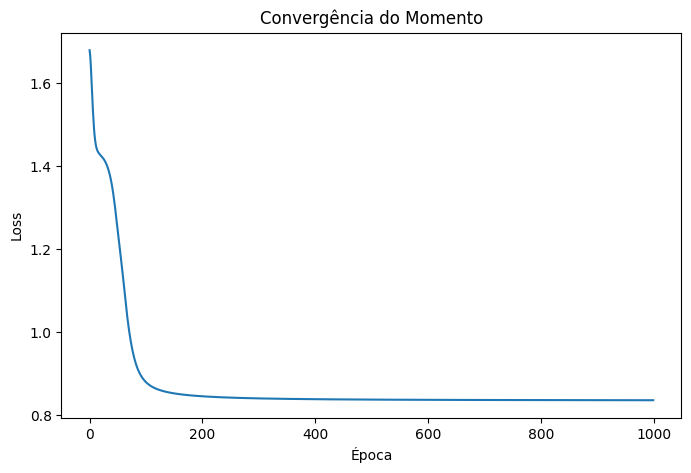

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(historico_loss)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Convergência do Momento")
plt.show()

A curva mostra descida íngreme nas primeiras épocas e estabilização em seguida, comportamento típico do gradiente descendente com momento acumulando velocidade no início do treino.

### 4. AdaGrad

Alguns parâmetros da rede precisam de passos maiores e outros de passos menores. O AdaGrad é o responsável por fazer essa adaptação dos passos conforme o parâmetro.

Parâmetros que receberam gradientes grandes no passado recebem uma taxa de aprendizado menor, enquanto parâmetros que receberam pequenos gradientes no passado recebem uma taxa de aprendizado maior.

Agora, a regra de atualização dos pesos se torna:

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \cdot \nabla L$$

Onde $G_t$ é a soma acumulada dos quadrados dos gradientes até o passo $t$, $\epsilon$ é um valor pequeno para evitar divisão por zero (tipicamente $10^{-8}$) e $\eta$ é a taxa de aprendizado.

Nota-se, portanto, que se um parâmetro possui gradientes cada vez maiores, sua taxa de aprendizado será cada vez menor. Em treinos longos ela fica tão pequena que o modelo praticamente para de aprender antes de convergir.

### 4.1 Implementação do AdaGrad em Python puro

A implementação do AdaGrad mantém um acumulador `G` para cada parâmetro da rede,que cresce a cada época com o quadrado do gradiente daquele parâmetro. A taxa de aprendizado efetiva de cada parâmetro é então dividida pela raiz desse acumulador,
fazendo com que parâmetros com histórico de gradientes grandes deem passos menores.

In [37]:
random.seed(333666)
mlp_adagrad = MLP(1, [4, 1])
params_adagrad = mlp_adagrad.parametros()

TAXA = 0.5
NUM_EPOCAS = 1000

G_adagrad = [0] * len(params_adagrad)
historico_loss_adagrad = []

for epoca in range(NUM_EPOCAS):
    previsoes = [mlp_adagrad([x[0]]) for x in X]
    loss = sum((yp - yt) ** 2 for yp, yt in zip(previsoes, y)) * (1 / len(y))

    for param in params_adagrad:
        param.grad = 0

    loss.propagar_tudo()

    for i, param in enumerate(params_adagrad):
        #Acumula continuamente o quadrado do gradiente
        G_adagrad[i] = G_adagrad[i] + param.grad ** 2
        # Atualiza o peso: a taxa de aprendizado (TAXA) é dividida pela raiz do acumulador.
        param.data -= (TAXA / (G_adagrad[i] ** 0.5 + 1e-8)) * param.grad

    historico_loss_adagrad.append(loss.data)

print(f"Loss final (AdaGrad): {historico_loss_adagrad[-1]:.6f}")

Loss final (AdaGrad): 0.836127


### 4.2 Curva de Convergência do AdaGrad

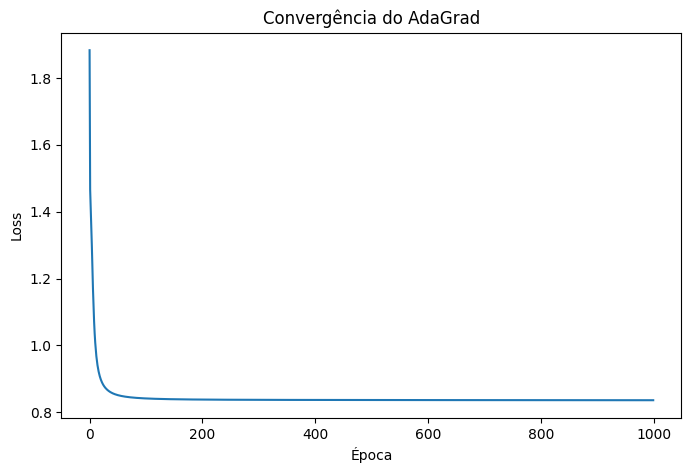

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(historico_loss_adagrad)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Convergência do AdaGrad")
plt.show()

O AdaGrad converge rapidamente e estabiliza. Neste dataset simples, o decaimento monotônico da taxa de aprendizado não prejudica a convergência, limitação que se tornaria evidente em problemas maiores e treinos mais longos.

### 5. RMSProp

Em vez de acumular de maneira indefinida os gradientes, o RMSProp utiliza de uma média móvel que dá maior peso para os gradientes recentes e esquece os antigos. Isso resolve o problema do decaimento monótono da taxa de aprendizado caso haja apenas gradientes grandes para um parâmetro, fazendo com que o valor de $G_t$ se estabilize.

$$G_t = \gamma \cdot G_{t-1} + (1 - \gamma) \cdot (\nabla L)^2$$

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \cdot \nabla L$$

Onde $\gamma$ é o coeficiente de decaimento (tipicamente $0,9$), $G_{t-1}$ é
o valor acumulado do passo anterior e $\nabla L$ é o gradiente da função de perda.

### 5.1 Implementação do RMSProp em Python puro

A diferença central em relação ao AdaGrad está na atualização do acumulador `G`: em vez de somar indefinidamente os quadrados dos gradientes, o RMSProp aplica uma média móvel exponencial controlada pelo coeficiente `GAMMA`. Gradientes antigos perdem peso ao longo do tempo, evitando que a taxa de aprendizado decaia para zero.

In [15]:
random.seed(333666)
mlp_rmsprop = MLP(1, [4, 1])
params_rmsprop = mlp_rmsprop.parametros()

GAMMA = 0.9

G_rmsprop = [0] * len(params_rmsprop)
historico_loss_rmsprop = []

for epoca in range(NUM_EPOCAS):
    previsoes = [mlp_rmsprop([x[0]]) for x in X]
    loss = sum((yp - yt) ** 2 for yp, yt in zip(previsoes, y)) * (1 / len(y))

    for param in params_rmsprop:
        param.grad = 0

    loss.propagar_tudo()

    for i, param in enumerate(params_rmsprop):
        G_rmsprop[i] = GAMMA * G_rmsprop[i] + (1 - GAMMA) * param.grad ** 2
        param.data -= (TAXA / (G_rmsprop[i] ** 0.5 + 1e-8)) * param.grad

    historico_loss_rmsprop.append(loss.data)

print(f"Loss final (RMSProp): {historico_loss_rmsprop[-1]:.6f}")

Loss final (RMSProp): 29.387179


### 5.2 Curva de Convergência do RMSPRop

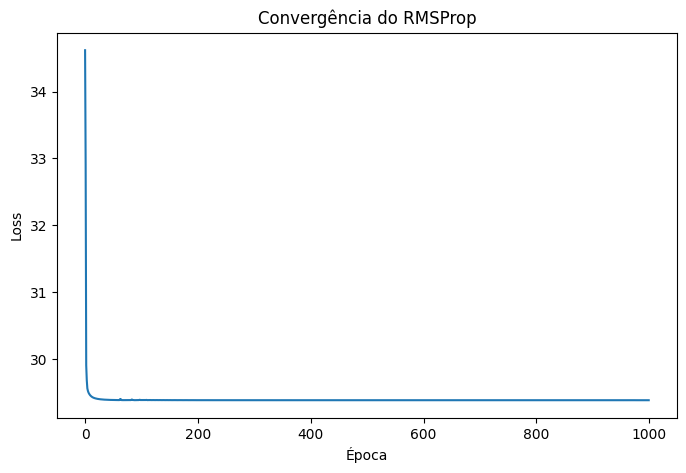

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(historico_loss_rmsprop)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Convergência do RMSProp")
plt.show()

A convergência do RMSProp é similar ao AdaGrad neste problema simples, mas com uma diferença estrutural importante: o acumulador `G` se estabiliza graças à média móvel, preservando a capacidade de aprendizado em treinos mais longos.

### 6. Adam

O Adam *(Adaptive Moment Estimation)* é o otimizador mais utilizado na prática atualmente. Ele combina as ideias do Momento e do RMSProp: utiliza o momento para definir a direção do passo e o RMSProp para definir a escala do passo.

**Momento de primeira ordem** (direção):
$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot \nabla L$$

**Momento de segunda ordem** (escala):
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot (\nabla L)^2$$

Como $m_t$ e $v_t$ são inicializados como zero, os primeiros passos seriam artificialmente pequenos sem uma correção. Por isso, o Adam aplica uma correção de viés:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

A atualização dos pesos é então:

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

Onde $\beta_1 = 0,9$, $\beta_2 = 0,999$ e $\epsilon = 10^{-8}$ são os valores típicos.

### 6.1 Implementação do Adam em Python puro

O Adam combina o Momento e o RMSProp em um único otimizador. Para cada parâmetro, mantemos dois acumuladores: `m` (média móvel dos gradientes, que define a direção do passo) e `v` (média móvel dos quadrados dos gradientes, que define a escala do passo). Como ambos são inicializados em zero, os primeiros passos seriam artificialmente pequenos, por isso o Adam aplica uma correção de viés dividindo cada acumulador por $(1 - \beta^t)$, onde $t$ é o número da época atual.

In [40]:
random.seed(333666)
mlp_adam = MLP(1, [4, 1])
params_adam = mlp_adam.parametros()

BETA1 = 0.9
BETA2 = 0.999

m_adam = [0] * len(params_adam)
v_adam = [0] * len(params_adam)
t_adam = 1

historico_loss_adam = []

for epoca in range(NUM_EPOCAS):
    previsoes = [mlp_adam([x[0]]) for x in X]
    loss = sum((yp - yt) ** 2 for yp, yt in zip(previsoes, y)) * (1 / len(y))

    for param in params_adam:
        param.grad = 0

    loss.propagar_tudo()

    for i, param in enumerate(params_adam):
        m_adam[i] = BETA1 * m_adam[i] + (1 - BETA1) * param.grad
        v_adam[i] = BETA2 * v_adam[i] + (1 - BETA2) * param.grad ** 2
        m_hat = m_adam[i] / (1 - BETA1 ** t_adam)
        v_hat = v_adam[i] / (1 - BETA2 ** t_adam)
        param.data -= (TAXA / (v_hat ** 0.5 + 1e-8)) * m_hat

    t_adam += 1
    historico_loss_adam.append(loss.data)

print(f"Loss final (Adam): {historico_loss_adam[-1]:.6f}")

Loss final (Adam): 0.833843


### 6.2 Curva de Convergência do Adam

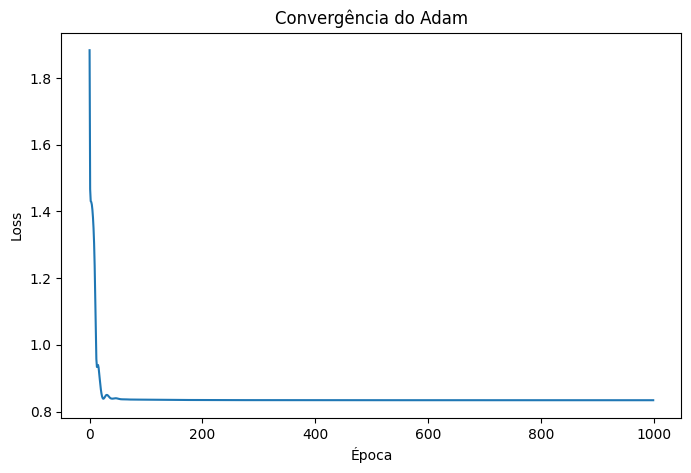

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(historico_loss_adam)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Convergência do Adam")
plt.show()

O Adam apresenta uma descida inicial mais suave que os demais, reflexo da correção de viés atuando nas primeiras épocas. A convergência final é similar aos outros otimizadores neste dataset simples.

## 7. Learning Rate Scheduling

Até agora usamos uma taxa de aprendizado fixa durante todo o treino. O learning rate scheduling é a estratégia de alterar a taxa de aprendizado ao longo do treino. A ideia é usar uma taxa maior no início para convergir rápido, e reduzi-la conforme o modelo se aproxima do mínimo para não oscilar.

Existem diversas estratégias de scheduling disponíveis no PyTorch:

- **StepLR**: reduz a taxa por um fator fixo a cada certo número de épocas.
- **ExponentialLR**: reduz a taxa exponencialmente a cada época.
- **CosineAnnealingLR**: reduz a taxa seguindo uma curva de cosseno que começa alta, vai caindo suavemente até quase zero.
- **ReduceLROnPlateau**: monitora a loss e reduz a taxa apenas quando ela para de melhorar.
- **CyclicalLR**: alterna a taxa entre um valor mínimo e máximo em ciclos, podendo ajudar o modelo a escapar de mínimos locais.

Demonstraremos o `ReduceLROnPlateau`.

C:\Users\victor25015\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


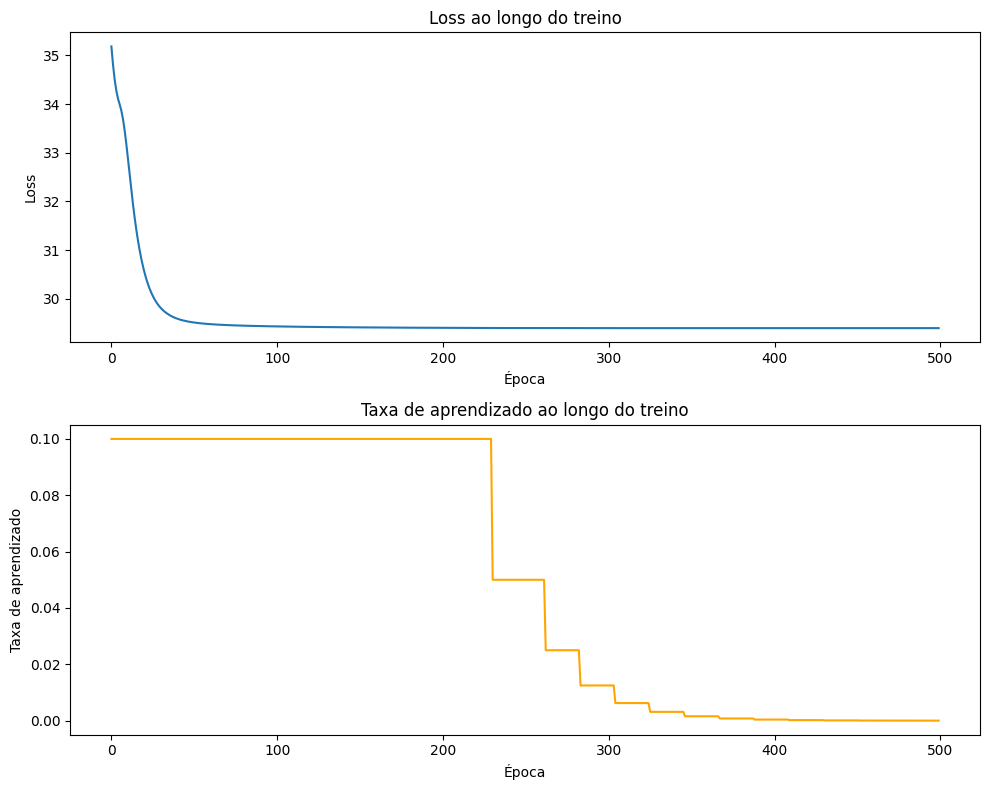

In [23]:
torch.manual_seed(333666)

modelo_plateau = criar_modelo()
otimizador_plateau = optim.Adam(modelo_plateau.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(otimizador_plateau, patience=20, factor=0.5)

fn_perda = nn.MSELoss()
historico_loss = []
historico_lr = []

modelo_plateau.train()

for epoca in range(500):
    y_pred = modelo_plateau(X_tensor)
    otimizador_plateau.zero_grad()
    loss = fn_perda(y_pred, y_tensor)
    loss.backward()
    otimizador_plateau.step()
    scheduler.step(loss)
    
    historico_loss.append(loss.item())
    historico_lr.append(otimizador_plateau.param_groups[0]["lr"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(historico_loss)
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.set_title("Loss ao longo do treino")

ax2.plot(historico_lr, color="orange")
ax2.set_xlabel("Época")
ax2.set_ylabel("Taxa de aprendizado")
ax2.set_title("Taxa de aprendizado ao longo do treino")

plt.tight_layout()
plt.show()

O gráfico acima demonstra o comportamento do `ReduceLROnPlateau` durante o treino.

No gráfico superior, é possível observar a loss caindo rapidamente nas primeiras épocas e estabilizando em seguida. No gráfico inferior, a taxa de aprendizado permaneceu em 0,1 durante quase todo o treino, sendo reduzida ao seu mínimo apenas ao final do treino. Esse é exatamente o comportamento esperado: o scheduler age apenas quando necessário, sem reduções desnecessárias da taxa de aprendizado.

## 8. Referências

[1] CASSAR, Daniel R. *Multilayer Perceptron em Python puro*. Material didático
da disciplina ATP-303 — Ilum Escola de Ciência, 2024.

[2] NANDI, Sushmita. *Types of Optimizers in Deep Learning: A Comprehensive
Guide*. Medium, 2023. Disponível em:
https://medium.com/@sushmita2310/types-of-optimizers-in-deep-learning-a-comprehensive-guide-af258d6acf66

[3] BROWNLEE, Jason. *How to use Learning Curves to Diagnose Machine Learning
Model Performance*. Machine Learning Mastery. Disponível em:
https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/

[4] BROWNLEE, Jason. *A Gentle Introduction to Learning Rate Schedulers*.
Machine Learning Mastery. Disponível em:
https://machinelearningmastery.com/a-gentle-introduction-to-learning-rate-schedulers/

[5] NORMALIZED NERD. *Optimization for Deep Learning (Momentum, RMSprop,
AdaGrad, Adam)*. YouTube, 2021. Disponível em:
https://www.youtube.com/watch?v=NE88eqLngkg

[6] CODINGMAVERICK. *Adam Optimizer Explained in Detail | Deep Learning*.
YouTube. Disponível em:
https://www.youtube.com/watch?v=tuU59-G1PgU

[7] MUTUAL INFORMATION. *Machine learning solvers BEYOND Gradient Descent
(SGD, Momentum, Adagrad, Adam)*. YouTube. Disponível em:
https://www.youtube.com/watch?v=sgTFtCYs94o

[8] CLAUDE (Anthropic). *Implementando otimizadores de redes neurais em Python
puro*. Conversa via Claude.ai, 2025. Disponível em:
https://claude.ai/chat/4fa29996-49f6-4278-b366-24746ca17a04

[9] CLAUDE (Anthropic). *Planejamento de 7 dias sobre otimizadores*.
Conversa via Claude.ai, 2025. Disponível em:
https://claude.ai/chat/395dd670-37cc-4e1d-a6cc-19d82b22a6f7
